# Lesson 2: the same LeRobot dataset, seen from FiftyOne

Lesson 1 went frame by frame: `ds[i]` was one 1/50 s snapshot. FiftyOne flips the unit: **one sample = one episode**. That change is what makes dataset-level questions cheap.

You will be able to:

1. Download a LeRobot dataset from the Hub and import it into FiftyOne, then read what each field means
2. Ask dataset-level questions (aggregations, views) and look at episodes in the App
3. Read an episode's frames in place through the sample's pointer
4. Turn a view into a `torch.utils.data.Dataset`, per episode or per frame
5. Export a view as a standalone LeRobot v3 dataset

Dataset: `lerobot/aloha_sim_insertion_human` from the Hub, imported as `lerobot-aloha-sim-insertion-human`. Env: `fo_lerobot`.

Section 1 downloads ~90 MB into `./data/` and creates the FiftyOne dataset (or loads it if it already exists). Beyond that the notebook does not modify the dataset. It writes one export to `./exports/`; the last cell removes it.

## 1. From the Hub into FiftyOne

A LeRobot dataset on the Hub is a folder (`meta/`, `data/`, `videos/`). Download it, point `fo.Dataset.from_dir` at it with `dataset_type=fo.types.LeRobotDataset`, check the episode count. Three things to know:

- Ask for revision `v3.0`. FiftyOne reads LeRobot v3 only.
- Import from the directory, never by adding samples: each sample is a **reference** into the folder, and the folder must stay where it is.
- `persistent=True`, or the dataset disappears when the kernel does.

The import reads only `meta/info.json` and `meta/episodes/*.parquet`; no video or data shard is opened, so it takes a second.

In [1]:
import json
import logging
import os
import shutil
from pathlib import Path

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
logging.getLogger("lerobot").setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

import fiftyone as fo
import fiftyone.utils.torch as fout
from fiftyone import ViewField as F
from lerobot.datasets.lerobot_dataset import LeRobotDataset

REPO_ID = "lerobot/aloha_sim_insertion_human"
DATASET_NAME = "lerobot-aloha-sim-insertion-human"
DATA_DIR = Path.cwd() / "data" / "aloha_sim_insertion_human"

In [2]:
!hf download {REPO_ID} --repo-type dataset --revision v3.0 --local-dir {DATA_DIR}

path=/home/harpreet/workspace/fo_lerobot_zoo_model_testbed/data/aloha_sim_insertion_human


In [ ]:

dataset = fo.Dataset.from_dir(
    dataset_dir=DATA_DIR,
    dataset_type=fo.types.LeRobotDataset,
    name=DATASET_NAME,
    persistent=True,
    overwrite=True,
)

print(dataset)

Name:        lerobot-aloha-sim-insertion-human
Media type:  multimodal
Num samples: 50
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    media_reference:  fiftyone.core.fields.MediaReferenceField(fiftyone.core.media_reference.MediaReference)
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.Metadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    episode_index:    fiftyone.core.fields.IntField
    task:             fiftyone.core.fields.StringField
    tasks:            fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    length:           fiftyone.core.fields.IntField
    duration:         fiftyone.core.fields.FloatField
    robot_type:       fiftyone.core.fields.StringField
    fps:              fiftyone.core.fields.F

Validate against the source's own `meta/info.json`: every episode imported, none skipped. `dataset.media_sources` records the folder the samples point at.

`media_type` is `multimodal`, not `video`: an episode is a bundle of streams (camera video + state + action tables). Compare with Lesson 1: `Num samples: 50` here, `num_frames: 25000` there. Same data, different unit.

In [4]:
source_root = Path(dataset.media_sources[0]["loc"])
info = json.loads((source_root / "meta" / "info.json").read_text())

print("source:          ", source_root)
print("codebase_version:", info["codebase_version"])
print("episodes:        ", len(dataset), "imported /", info["total_episodes"], "in source")
print("skipped:         ", dataset.info["lerobot"]["skipped_episodes"])

source:           /home/harpreet/lerobot-data/aloha_sim_insertion_human
codebase_version: v3.0
episodes:         50 imported / 50 in source
skipped:          []


## 2. One sample = one episode

The importer read only `meta/info.json` and `meta/episodes/*.parquet`. Every field on the sample comes from those two places:

- `episode_index`, `length`, `duration`, `fps`, `robot_type`, `task` / `tasks` — plain scalars, filterable
- `media_reference` — the episode's coordinates inside the source:
  - `data = [chunk, file, row_start, row_end]` — the same numbers as Lesson 1's `dataset_from_index` / `dataset_to_index`
  - `videos[camera] = [chunk, file, from_s, to_s]` — the time window in the shared mp4

![a FiftyOne sample is one episode with a pointer into the source](figures/08_episode_sample.png)

Nothing frame-level lives in FiftyOne's database. The App reads frames through the reference when you open an episode.

The cell selects episode 0 with `match(F("episode_index") == 0)` rather than `dataset.first()`. Both return the same sample here, but `first()` means "whatever is stored first" and `match` means "episode 0"; only the second keeps working after a sort, a deletion, or a second source added with `add_dir`.

In [5]:
sample = dataset.match(F("episode_index") == 0).first()

for name in ["episode_index", "task", "length", "duration", "fps", "robot_type"]:
    print(f"{name:14s} {sample[name]!r}")

ref = sample.media_reference
print()
print("media_reference.key   ", ref.key, "   <- <source id>/<episode index>")
print("media_reference.data  ", ref.data, "   <- [chunk, file, row_start, row_end]")
print("media_reference.videos", ref.videos, "   <- [chunk, file, from_s, to_s]")

episode_index  0
task           'Insert the peg into the socket.'
length         500
duration       10.0
fps            50.0
robot_type     'aloha'

media_reference.key    6aa2f301b3580af005249e71/0    <- <source id>/<episode index>
media_reference.data   [0, 0, 0, 500]    <- [chunk, file, row_start, row_end]
media_reference.videos {'observation.images.top': [0, 0, 0.0, 10.0]}    <- [chunk, file, from_s, to_s]


## 3. Dataset-level questions

In Lesson 1, "how long is each episode?" meant looping over `ds.meta.episodes`. Here every episode is a row in a queryable collection:

- `count_values` / `distinct` / `bounds` / `mean` / `sum` — **aggregations** over samples
- `sort_by`, `match`, `limit`, `take` — build a **view** (a saved query, nothing copied)

Read `bounds("duration")` carefully. In this dataset every episode is exactly 500 frames / 10.0 s (the simulator records fixed-horizon episodes), so `duration` cannot tell demonstrations apart. Telling them apart needs per-episode numbers computed from the action curves; that is Lesson 3.

In [6]:
print("tasks:          ", dataset.count_values("task"))
print("robot types:    ", dataset.distinct("robot_type"))
print("length bounds:  ", dataset.bounds("length"), "frames")
print("duration bounds:", dataset.bounds("duration"), "s")
print("total frames:   ", dataset.sum("length"))

longest = dataset.sort_by("duration", reverse=True).limit(3)
print()
print("3 longest episodes:", *longest.values(["episode_index", "duration"]))

subset = dataset.take(10, seed=51)                 # a random 10-episode view, reused in sections 6 and 7
print("random 10:", sorted(subset.values("episode_index")))

tasks:           {'Insert the peg into the socket.': 50}
robot types:     ['aloha']
length bounds:   (500, 500) frames
duration bounds: (10.0, 10.0) s
total frames:    25000



3 longest episodes: [0, 1, 2] [10.0, 10.0, 10.0]
random 10: [4, 8, 11, 18, 20, 27, 30, 31, 36, 40]


## 4. The App

Open an episode. The LeRobot viewer gives you, per episode:

- one image tile per camera, scrubbing the video
- a **State & Action** tile showing the 14 + 14 values at the current frame
- **Plot** tiles for any state/action dimension over time
- a **Streams** tab listing Observations / Actions / Instructions
- a **Statistics** tab in the sidebar

The sidebar filters on the scalar fields (`duration`, `task`, ...). Setting `session.view = some_view` pushes a query to the App.

In [7]:
session = fo.launch_app(dataset, auto=False)
print("App:", session.url)

session.view = subset

Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.


App: http://localhost:5151/


## 5. Getting frames back out of FiftyOne

A FiftyOne sample does not contain the frames. It contains a **pointer** to them: which folder, which rows, which seconds of which video. So every time you want actual state/action/image data, you follow the pointer. There are three ways, and the choice depends on one question: **who is going to consume the frames?**

![three roads from a view back to frames](figures/10_three_roads.png)

Rule of thumb: in-process, do not copy (roads 1 and 2). Out-of-process, copy (road 3).

### Road 1: read in place

The pointer is two values:

- `dataset.media_sources[0]["loc"]`: the LeRobot folder on disk. Stored once per dataset.
- `sample.media_reference.data`: `[chunk, file, row_start, row_end]`. Stored once per sample. `row_start:row_end` is the episode's slice of the frame table.

![road 1: two values from FiftyOne, one slice in LeRobot](figures/09_pointer_road.png)

Open the folder with Lesson 1's `LeRobotDataset(root=...)`, take the `action` column, slice the rows. The plot that comes out is Lesson 1 section 5 again, which is the point: same frames, reached from a FiftyOne sample instead of a hard-coded index.

The full `action` table `A` (25 000 × 14) stays in memory; section 6 reuses it.

root: /home/harpreet/lerobot-data/aloha_sim_insertion_human
episode 0: rows 0:500 -> actions (500, 14)


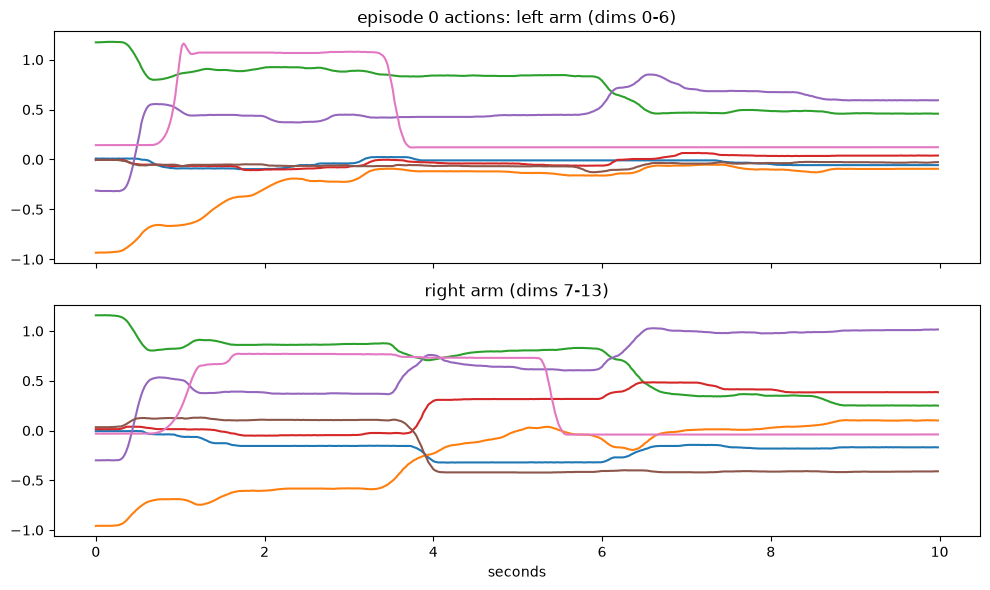

In [8]:
root = dataset.media_sources[0]["loc"]                       # where the LeRobot files are
_, _, row_start, row_end = sample.media_reference.data       # which rows are this episode

lr = LeRobotDataset("lerobot/aloha_sim_insertion_human", root=root)
A = np.asarray(lr.hf_dataset.with_format("numpy")["action"])  # (25000, 14)
fps = lr.fps

actions = A[row_start:row_end]                               # (500, 14), same array as Lesson 1 section 5
t = np.arange(len(actions)) / fps
print("root:", root)
print(f"episode {sample.episode_index}: rows {row_start}:{row_end} -> actions {actions.shape}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t, actions[:, :7]);  axes[0].set_title(f"episode {sample.episode_index} actions: left arm (dims 0-6)")
axes[1].plot(t, actions[:, 7:]);  axes[1].set_title("right arm (dims 7-13)")
axes[1].set_xlabel("seconds")
plt.tight_layout(); plt.show()

## 6. From a view to a `torch.utils.data.Dataset`

Lesson 1 ended with a `DataLoader` because that is what a model consumes. FiftyOne gets you there without exporting, and there are two ways depending on what one *item* should be.

![road 2 has two shapes: item = episode, or item = frame](figures/11_torch_two_ways.png)

### 6a. One item = one episode: `view.to_torch(get_item)`

Any FiftyOne collection converts to a torch `Dataset` with `to_torch()`. You supply a `GetItem`: it declares `required_keys` (the sample fields it needs) and its `__call__` turns the dict of those fields into tensors. FiftyOne handles the sample iteration and multi-worker process setup (`worker_init_fn=fout.FiftyOneTorchDataset.worker_init`), and keeps the dataset out of the pickle.

For a LeRobot episode the `GetItem` follows the pointer from section 5: `media_reference.data` gives the row range, and the action table `A` gives the rows. Here each item is the 25-step resampled trajectory plus the task string. Use this shape for episode-level models: trajectory classifiers, quality scorers, anything that consumes a whole demonstration at once.

Two rules from the FiftyOne docs: do not index the torch dataset in the main process before the workers start, and pass `vectorize=True` if database reads become the bottleneck (it caches `required_keys` up front).

In [9]:
def describe(batch):
    """One line per entry of a batch dict: shape and dtype, or the list length and first value."""
    for k, v in batch.items():
        if hasattr(v, "shape"):
            print(f"{k:28s} {str(tuple(v.shape)):22s} {v.dtype}")
        else:
            print(f"{k:28s} {type(v).__name__} of {len(v)} -> {v[0]!r}")


class EpisodeGetItem(fout.GetItem):
    """One item per episode: resampled action trajectory + task string."""

    def __init__(self, actions, n_steps=25, **kwargs):
        super().__init__(**kwargs)
        self.actions = actions.astype(np.float32)   # (25000, 14) shared table, pickled to workers once
        self.n_steps = n_steps

    @property
    def required_keys(self):
        return ["media_reference", "episode_index", "task"]

    def __call__(self, d):
        _, _, row_start, row_end = d["media_reference"].data          # the pointer, per sample
        a = self.actions[row_start:row_end]
        idx = np.linspace(0, len(a) - 1, self.n_steps).astype(int)
        return {
            "traj": torch.from_numpy(a[idx]),                          # (25, 14)
            "episode_index": d["episode_index"],
            "task": d["task"],
        }


episode_torch_ds = subset.to_torch(EpisodeGetItem(A))                 # FiftyOne picks the episodes
print(type(episode_torch_ds).__name__, "with", len(episode_torch_ds), "items (episodes)")

episode_loader = DataLoader(
    episode_torch_ds,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    worker_init_fn=fout.FiftyOneTorchDataset.worker_init,
)
describe(next(iter(episode_loader)))

FiftyOneTorchDataset with 10 items (episodes)


traj                         (4, 25, 14)            torch.float32
episode_index                (4,)                   torch.int64
task                         list of 4 -> 'Insert the peg into the socket.'


### 6b. One item = one frame: `LeRobotDataset(episodes=view.values("episode_index"))`

A policy does not consume episodes; it consumes frames with `delta_timestamps` (Lesson 1, sections 7 and 8). `LeRobotDataset` already *is* that torch `Dataset`, and its `episodes=` argument takes a list of episode indexes. So the FiftyOne side reduces to one aggregation: `view.values("episode_index")`.

Same 10 episodes, now 5 000 frame-level items, and the batch dict is the shape Lesson 1 ended on. No export, no copy: LeRobot reads the source folder FiftyOne pointed at. This is the road Lesson 4 takes to feed a trained policy.

In [10]:
subset_episodes = subset.values("episode_index")                     # the whole FiftyOne -> LeRobot handoff

frame_torch_ds = LeRobotDataset(
    "lerobot/aloha_sim_insertion_human",
    root=root,
    episodes=subset_episodes,
    delta_timestamps={"action": [i / fps for i in range(10)]},         # current + 9 future actions, as in Lesson 1
)
print("frame-level torch dataset:", frame_torch_ds.num_episodes, "episodes,", frame_torch_ds.num_frames, "frames")

frame_loader = DataLoader(frame_torch_ds, batch_size=8, shuffle=True, num_workers=0)
describe(next(iter(frame_loader)))

frame-level torch dataset: 10 episodes, 5000 frames
observation.images.top       (8, 3, 480, 640)       torch.float32
observation.state            (8, 14)                torch.float32
action                       (8, 10, 14)            torch.float32
episode_index                (8,)                   torch.int64
frame_index                  (8,)                   torch.int64
timestamp                    (8,)                   torch.float32
next.done                    (8,)                   torch.bool
index                        (8,)                   torch.int64
task_index                   (8,)                   torch.int64
action_is_pad                (8, 10)                torch.bool
task                         list of 8 -> 'Insert the peg into the socket.'


## 7. Export a view as a new LeRobot dataset

The third road, for when the consumer is outside your Python process (a training job on another machine, a Hub upload, a colleague). `view.export(dataset_type=fo.types.LeRobotDataset)` writes a **standalone LeRobot v3 dataset** containing only the episodes in the view: episodes renumbered from 0, task and global frame indexes rebuilt, only the needed video and parquet copied, and the result validated against the `lerobot` reader.

Rules: all episodes must come from one source, and the export is always self-contained (`export_media=True` is the only mode). The export lands in `./exports/aloha_sim_insertion_10ep` next to this notebook; the cell removes that folder first so it can be re-run.

Verification is Lesson 1: open the export with `LeRobotDataset(root=...)` and check the counts.

In [11]:
export_dir = Path.cwd() / "exports" / "aloha_sim_insertion_10ep"
shutil.rmtree(export_dir, ignore_errors=True)

print("exporting", len(subset), "episodes ->", export_dir)
subset.export(export_dir=str(export_dir), dataset_type=fo.types.LeRobotDataset)

exported = LeRobotDataset("local/aloha_sim_insertion_10ep", root=export_dir)
print("reopened with lerobot:", exported.num_episodes, "episodes,", exported.num_frames, "frames")
print("episode indexes renumbered:", [exported.meta.episodes[i]["episode_index"] for i in range(exported.num_episodes)])
print("features unchanged:", list(exported.meta.features) == list(lr.meta.features))

exporting 10 episodes -> /home/harpreet/workspace/fo_lerobot_zoo_model_testbed/exports/aloha_sim_insertion_10ep



   0% ||------------------|  0/10 [1.1ms elapsed, ? remaining, ? samples/s] 


 100% |███████████████████| 10/10 [3.1ms elapsed, 0s remaining, 3.3K samples/s] 


INFO:eta.core.utils: 100% |███████████████████| 10/10 [3.1ms elapsed, 0s remaining, 3.3K samples/s] 


reopened with lerobot: 10 episodes, 5000 frames
episode indexes renumbered: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
features unchanged: True


## Recap

- FiftyOne sample = episode; `media_reference` holds the row range and video window, the App reads frames through it
- Aggregations answer dataset-level questions; views (`match`, `sort_by`, `take`) are the unit of selection
- Three roads back to LeRobot: read in place through the pointer (a `Model`'s job); `view.to_torch(GetItem)` for episode items or `LeRobotDataset(episodes=view.values("episode_index"))` for frame items (a training loop's job); `export` a view as a new LeRobot dataset (handoff outside the process)

Next (Lesson 3): compute per-episode kinematics, attach them as fields and temporal tags, find outlier demonstrations with FiftyOne Brain, and export the clean set.

Cleanup: remove the export written by section 7.

In [12]:
shutil.rmtree(export_dir, ignore_errors=True)
print("removed", export_dir)

removed /home/harpreet/workspace/fo_lerobot_zoo_model_testbed/exports/aloha_sim_insertion_10ep
